In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("home_credit_processed.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (307511, 212)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,INCOME_PER_FAMILY_MEMBER,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,GOODS_CREDIT_RATIO,CONTACT_COUNT,CODE_GENDER_M,CODE_GENDER_XNA,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_TYPE_SUITE_Unknown,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Cleaning,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_TYPE_Industry: type 13,ORGANIZATION_TYPE_Industry: type 2,ORGANIZATION_TYPE_Industry: type 3,ORGANIZATION_TYPE_Industry: type 4,ORGANIZATION_TYPE_Industry: type 5,ORGANIZATION_TYPE_Industry: type 6,ORGANIZATION_TYPE_Industry: type 7,ORGANIZATION_TYPE_Industry: type 8,ORGANIZATION_TYPE_Ind

In [3]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Target Distribution:\n")
print(df["TARGET"].value_counts())

Missing Values: 0
Duplicate Rows: 0
Target Distribution:

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [4]:
X = df.drop(columns=["TARGET"])

y = df["TARGET"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (307511, 211)
Target Shape: (307511,)


In [5]:
"SK_ID_CURR" in X.columns

True

In [6]:
X = X.drop(columns=["SK_ID_CURR"])

print("Updated Feature Shape:", X.shape)

Updated Feature Shape: (307511, 210)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (246008, 210)
X_test shape: (61503, 210)
y_train shape: (246008,)
y_test shape: (61503,)


In [8]:
train_default_rate = y_train.mean() * 100
test_default_rate = y_test.mean() * 100

print(f"Train Default Rate: {train_default_rate:.2f}%")
print(f"Test Default Rate: {test_default_rate:.2f}%")

Train Default Rate: 8.07%
Test Default Rate: 8.07%


TARGET
0    226148
1     19860
Name: count, dtype: int64


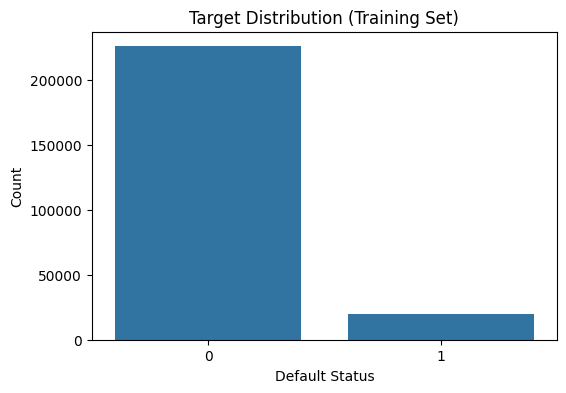

In [9]:
target_counts = y_train.value_counts()

print(target_counts)

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)

plt.title("Target Distribution (Training Set)")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.show()

In [10]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [11]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)
y_prob_dummy = dummy_model.predict_proba(X_test)[:, 1]

dummy_results = evaluate_model(
    "Dummy Classifier",
    y_test,
    y_pred_dummy,
    y_prob_dummy
)


Dummy Classifier
----------------------------------------
Accuracy : 0.9193
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5000


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (246008, 210)
Scaled Testing Shape: (61503, 210)


In [14]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)


Logistic Regression
----------------------------------------
Accuracy : 0.6885
Precision: 0.1614
Recall   : 0.6814
F1 Score : 0.2610
ROC-AUC  : 0.7503


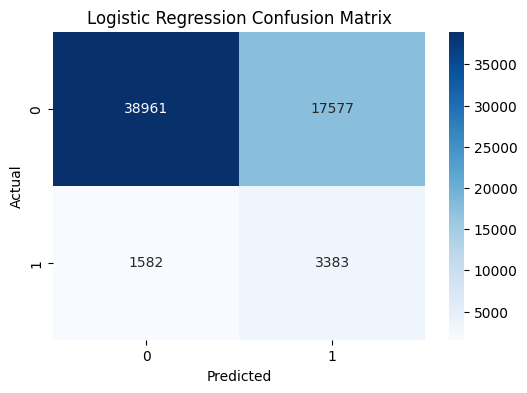

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest
----------------------------------------
Accuracy : 0.9195
Precision: 0.7500
Recall   : 0.0042
F1 Score : 0.0084
ROC-AUC  : 0.7207


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest
----------------------------------------
Accuracy : 0.9194
Precision: 0.5849
Recall   : 0.0062
F1 Score : 0.0124
ROC-AUC  : 0.7324


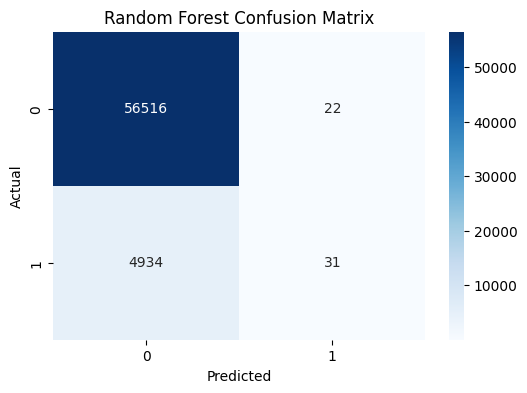

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
from xgboost import XGBClassifier

In [20]:
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight = negative_class / positive_class

print("Negative Class:", negative_class)
print("Positive Class:", positive_class)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Negative Class: 226148
Positive Class: 19860
scale_pos_weight: 11.39


In [21]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


XGBoost
----------------------------------------
Accuracy : 0.7199
Precision: 0.1765
Recall   : 0.6737
F1 Score : 0.2797
ROC-AUC  : 0.7667


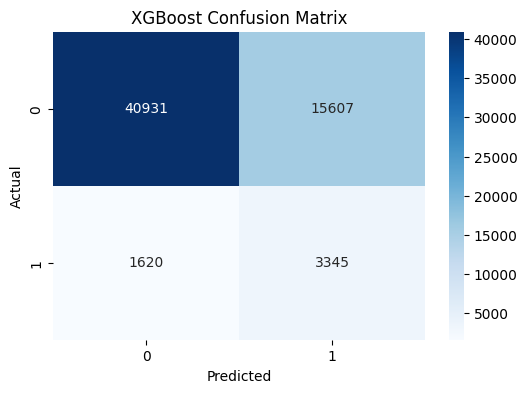

In [22]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
78,EXT_SOURCE_MEAN,0.078111
98,NAME_EDUCATION_TYPE_Higher education,0.019306
83,CODE_GENDER_M,0.014706
101,NAME_EDUCATION_TYPE_Secondary / secondary special,0.012521
209,AGE_GROUP_55+,0.012284
81,GOODS_CREDIT_RATIO,0.011758
97,NAME_INCOME_TYPE_Working,0.011275
80,EXT_SOURCE_MIN,0.010761
29,EXT_SOURCE_3,0.010554
1,FLAG_OWN_CAR,0.010136


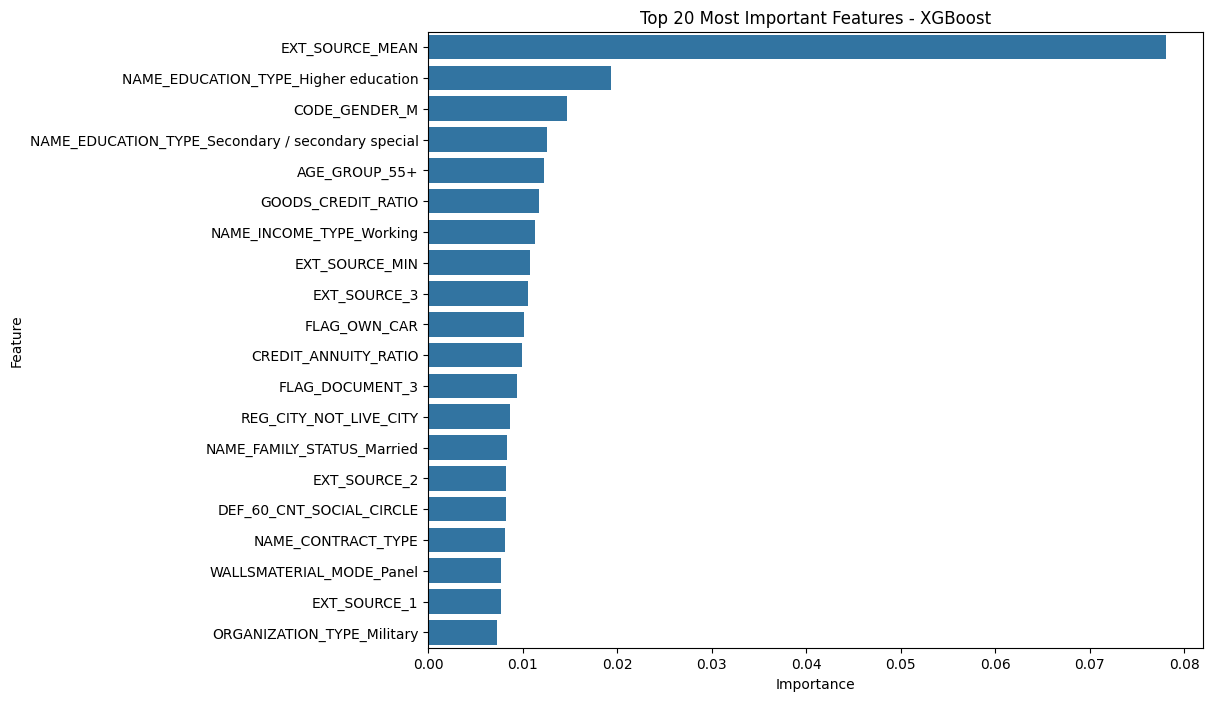

In [24]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features - XGBoost")

plt.show()

In [25]:
results_df = pd.DataFrame([
    dummy_results,
    lr_results,
    rf_results,
    xgb_results
])

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.719900,0.176499,0.673716,0.279717,0.766705
1,Logistic Regression,0.688487,0.161403,0.681370,0.260984,0.750258
2,Random Forest,0.919419,0.584906,0.006244,0.012356,0.732399
0,Dummy Classifier,0.919272,0.000000,0.000000,0.000000,0.500000


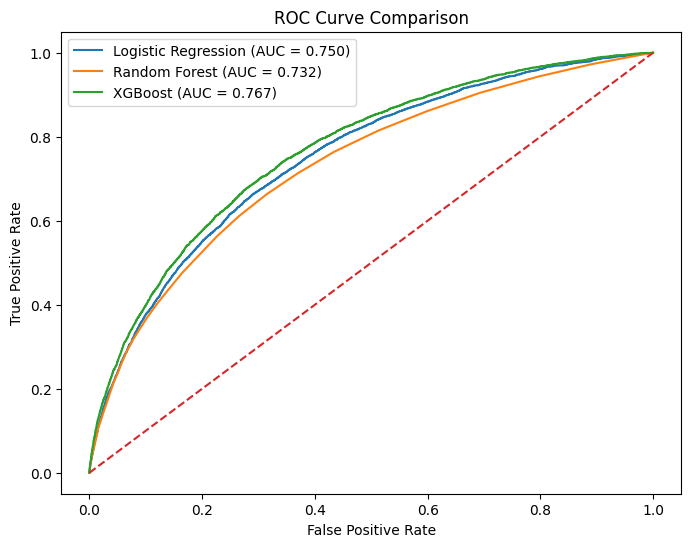

In [26]:
plt.figure(figsize=(8, 6))

models = [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]

for name, probs in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Business Recommendation

Among all evaluated models, XGBoost delivered the strongest overall performance with a ROC-AUC of 0.7667 while maintaining high recall for identifying defaulters.

Key findings:

- External credit score variables were the strongest predictors of default.
- Engineered financial ratio features contributed significantly to predictive performance.
- Logistic Regression provided strong interpretability and competitive performance.
- Random Forest achieved high accuracy but failed to identify default cases effectively.
- XGBoost provided the best balance between predictive power and risk discrimination.

Recommendation:

Deploy XGBoost as the primary credit risk scoring model while using Logistic Regression as an interpretable benchmark model for business validation and regulatory transparency.

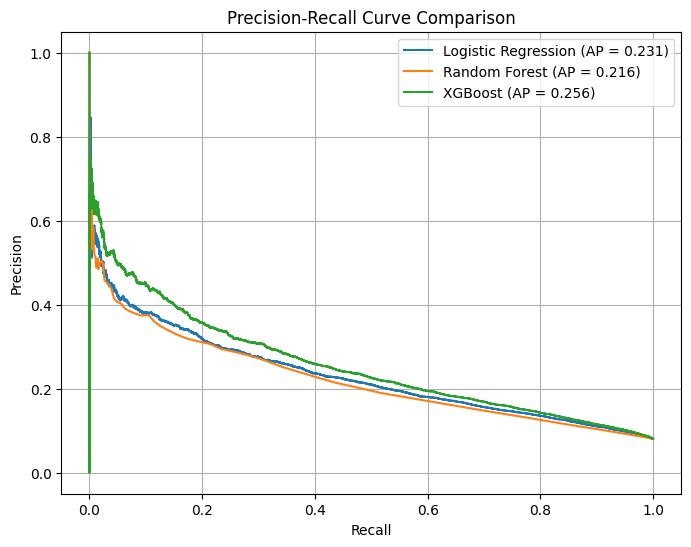

In [28]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, probs in models:

    precision, recall, _ = precision_recall_curve(
        y_test,
        probs
    )

    ap_score = average_precision_score(
        y_test,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap_score:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.grid(True)

plt.show()

Business Recommendations

1. Deploy XGBoost as the primary credit risk assessment model due to its superior ROC-AUC (0.7667) and Average Precision (0.256).

2. Use predicted default probabilities as an additional decision-support tool during loan approval rather than replacing existing credit assessment procedures.

3. Prioritize manual review for applicants identified as high-risk by the model to reduce potential credit losses.

4. Monitor model performance periodically and retrain using updated customer data to maintain predictive accuracy.

5. Combine model predictions with domain expertise and regulatory guidelines to support responsible lending decisions.

Business Impact

The proposed credit risk prediction system can help financial institutions identify potentially risky borrowers before loan approval.

Potential benefits include:

- Reduced loan default rates
- Improved risk management
- Faster loan processing
- Better allocation of manual review resources
- More data-driven lending decisions

By identifying high-risk applicants early, financial institutions can reduce financial losses while maintaining operational efficiency.

Conclusion

This project developed an end-to-end credit risk prediction pipeline using the Home Credit Default Risk dataset containing over 307,000 customer records.

Comprehensive data preprocessing and feature engineering were performed to capture applicant financial characteristics, employment history, family structure, and external credit information.

Multiple machine learning models were evaluated, including Logistic Regression, Random Forest, and XGBoost.

Model evaluation using ROC-AUC, Precision-Recall analysis, F1-score, Precision, and Recall demonstrated that XGBoost achieved the strongest overall performance with a ROC-AUC of 0.7667 and an Average Precision score of 0.256.

The results indicate that machine learning can effectively support credit risk assessment by identifying applicants with a higher likelihood of default, enabling more informed lending decisions.

In [29]:
risk_df = pd.DataFrame({
    "Default_Probability": y_prob_xgb
})

risk_df["Risk_Segment"] = pd.cut(
    risk_df["Default_Probability"],
    bins=[0, 0.2, 0.5, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df["Risk_Segment"].value_counts()

Risk_Segment
Medium Risk    30085
High Risk      18952
Low Risk       12466
Name: count, dtype: int64

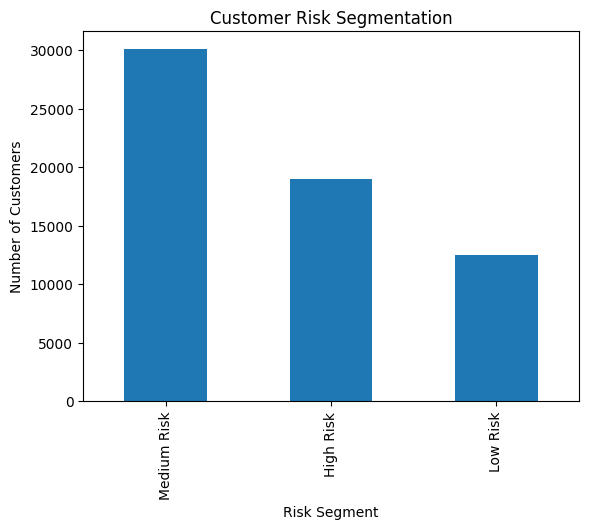

In [30]:
risk_df["Risk_Segment"].value_counts().plot(
    kind="bar",
    title="Customer Risk Segmentation"
)

plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.show()

Risk Segmentation

To make model predictions more actionable for business users, customers were categorized into three risk segments based on predicted default probabilities:

Default Probability	Risk Segment
< 20%	Low Risk
20% – 50%	Medium Risk
> 50%	High Risk

This segmentation enables financial institutions to prioritize loan approvals, manual reviews, and risk management decisions more effectively.

In [31]:
powerbi_df = X_test.copy()

powerbi_df["TARGET"] = y_test.values

powerbi_df["Default_Probability"] = y_prob_xgb

powerbi_df["Risk_Segment"] = pd.cut(
    y_prob_xgb,
    bins=[0, 0.2, 0.5, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

In [32]:
cols = [
    "TARGET",
    "Default_Probability",
    "Risk_Segment",

    "AGE",
    "AGE_GROUP",

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    "EXT_SOURCE_MEAN"
]

powerbi_df = powerbi_df[cols]

KeyError: "['AGE', 'AGE_GROUP'] not in index"

In [33]:
powerbi_df.columns.tolist()

['NAME_CONTRACT_TYPE',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'DEF_60_CN

In [34]:
powerbi_cols = [
    "TARGET",
    "Default_Probability",
    "Risk_Segment",

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",

    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",

    "DAYS_BIRTH",
    "DAYS_EMPLOYED",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",

    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",

    "CONTACT_COUNT",

    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",

    "AGE_GROUP_25-35",
    "AGE_GROUP_35-45",
    "AGE_GROUP_45-55",
    "AGE_GROUP_55+"
]

powerbi_dashboard_df = powerbi_df[powerbi_cols]

powerbi_dashboard_df.to_csv(
    "credit_risk_dashboard_data.csv",
    index=False
)

In [35]:
powerbi_df["Age_Group"] = "Under 25"

powerbi_df.loc[
    powerbi_df["AGE_GROUP_25-35"] == 1,
    "Age_Group"
] = "25-35"

powerbi_df.loc[
    powerbi_df["AGE_GROUP_35-45"] == 1,
    "Age_Group"
] = "35-45"

powerbi_df.loc[
    powerbi_df["AGE_GROUP_45-55"] == 1,
    "Age_Group"
] = "45-55"

powerbi_df.loc[
    powerbi_df["AGE_GROUP_55+"] == 1,
    "Age_Group"
] = "55+"

In [36]:
powerbi_dashboard_df.head()

,TARGET,Default_Probability,Risk_Segment,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_BIRTH,DAYS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,CONTACT_COUNT,FLAG_OWN_CAR,FLAG_OWN_REALTY,AGE_GROUP_25-35,AGE_GROUP_35-45,AGE_GROUP_45-55,AGE_GROUP_55+
256571,0,0.479181,Medium Risk,157500.0,770292.0,30676.5,1,3.0,-13506,-105,4.890743,0.194771,25.110166,0.509327,0.427657,2,1,1,False,True,False,False
191493,0,0.353603,Medium Risk,90000.0,364896.0,19926.0,0,2.0,-17723,-4930,4.054400,0.221400,18.312556,0.566009,0.484851,2,0,0,False,False,True,False
103497,0,0.749168,High Risk,148500.0,284400.0,18643.5,0,2.0,-24200,-1191,1.915152,0.125545,15.254646,0.358323,0.030108,3,0,1,False,False,False,True
130646,0,0.355935,Medium Risk,188100.0,976711.5,38218.5,0,1.0,-9650,-355,5.192512,0.203182,25.555987,0.486033,0.411849,3,0,0,True,False,False,False
211898,0,0.516508,High Risk,180000.0,323194.5,19660.5,0,2.0,-17487,-1366,1.795525,0.109225,16.438773,0.484947,0.355126,2,0,1,False,False,True,False


In [37]:
powerbi_df["Age"] = (-powerbi_df["DAYS_BIRTH"] / 365).astype(int)

In [38]:
powerbi_df["Years_Employed"] = (
    -powerbi_df["DAYS_EMPLOYED"] / 365
).round(1)

In [39]:
powerbi_df["Years_Employed"] = (
    -powerbi_df["DAYS_EMPLOYED"] / 365
).round(1)

In [40]:
for col in powerbi_dashboard_df.columns:
    print(col)

TARGET
Default_Probability
Risk_Segment
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
CNT_CHILDREN
CNT_FAM_MEMBERS
DAYS_BIRTH
DAYS_EMPLOYED
CREDIT_INCOME_RATIO
ANNUITY_INCOME_RATIO
CREDIT_ANNUITY_RATIO
EXT_SOURCE_MEAN
EXT_SOURCE_MIN
CONTACT_COUNT
FLAG_OWN_CAR
FLAG_OWN_REALTY
AGE_GROUP_25-35
AGE_GROUP_35-45
AGE_GROUP_45-55
AGE_GROUP_55+


In [41]:
powerbi_dashboard_df.head()

,TARGET,Default_Probability,Risk_Segment,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_BIRTH,DAYS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,CONTACT_COUNT,FLAG_OWN_CAR,FLAG_OWN_REALTY,AGE_GROUP_25-35,AGE_GROUP_35-45,AGE_GROUP_45-55,AGE_GROUP_55+
256571,0,0.479181,Medium Risk,157500.0,770292.0,30676.5,1,3.0,-13506,-105,4.890743,0.194771,25.110166,0.509327,0.427657,2,1,1,False,True,False,False
191493,0,0.353603,Medium Risk,90000.0,364896.0,19926.0,0,2.0,-17723,-4930,4.054400,0.221400,18.312556,0.566009,0.484851,2,0,0,False,False,True,False
103497,0,0.749168,High Risk,148500.0,284400.0,18643.5,0,2.0,-24200,-1191,1.915152,0.125545,15.254646,0.358323,0.030108,3,0,1,False,False,False,True
130646,0,0.355935,Medium Risk,188100.0,976711.5,38218.5,0,1.0,-9650,-355,5.192512,0.203182,25.555987,0.486033,0.411849,3,0,0,True,False,False,False
211898,0,0.516508,High Risk,180000.0,323194.5,19660.5,0,2.0,-17487,-1366,1.795525,0.109225,16.438773,0.484947,0.355126,2,0,1,False,False,True,False


In [42]:
powerbi_dashboard_df["Age"] = (
    -powerbi_dashboard_df["DAYS_BIRTH"] / 365
).astype(int)

In [43]:
powerbi_dashboard_df["Years_Employed"] = (
    -powerbi_dashboard_df["DAYS_EMPLOYED"] / 365
).round(1)

In [44]:
for col in powerbi_dashboard_df.columns:
    print(col)

TARGET
Default_Probability
Risk_Segment
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
CNT_CHILDREN
CNT_FAM_MEMBERS
DAYS_BIRTH
DAYS_EMPLOYED
CREDIT_INCOME_RATIO
ANNUITY_INCOME_RATIO
CREDIT_ANNUITY_RATIO
EXT_SOURCE_MEAN
EXT_SOURCE_MIN
CONTACT_COUNT
FLAG_OWN_CAR
FLAG_OWN_REALTY
AGE_GROUP_25-35
AGE_GROUP_35-45
AGE_GROUP_45-55
AGE_GROUP_55+
Age
Years_Employed


In [45]:
final_cols = [
    "TARGET",
    "Default_Probability",
    "Risk_Segment",

    "Age",
    "Years_Employed",

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",

    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",

    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",

    "CONTACT_COUNT",

    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",

    "AGE_GROUP_25-35",
    "AGE_GROUP_35-45",
    "AGE_GROUP_45-55",
    "AGE_GROUP_55+"
]

powerbi_dashboard_df = powerbi_dashboard_df[final_cols]

In [46]:
powerbi_dashboard_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61503 entries, 256571 to 268861
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   TARGET                61503 non-null  int64   
 1   Default_Probability   61503 non-null  float32 
 2   Risk_Segment          61503 non-null  category
 3   Age                   61503 non-null  int64   
 4   Years_Employed        61503 non-null  float64 
 5   AMT_INCOME_TOTAL      61503 non-null  float64 
 6   AMT_CREDIT            61503 non-null  float64 
 7   AMT_ANNUITY           61503 non-null  float64 
 8   CNT_CHILDREN          61503 non-null  int64   
 9   CNT_FAM_MEMBERS       61503 non-null  float64 
 10  CREDIT_INCOME_RATIO   61503 non-null  float64 
 11  ANNUITY_INCOME_RATIO  61503 non-null  float64 
 12  CREDIT_ANNUITY_RATIO  61503 non-null  float64 
 13  EXT_SOURCE_MEAN       61503 non-null  float64 
 14  EXT_SOURCE_MIN        61503 non-null  float64 
 15  C

In [47]:
powerbi_dashboard_df["Age_Group"] = "Under 25"

powerbi_dashboard_df.loc[
    powerbi_dashboard_df["AGE_GROUP_25-35"] == 1,
    "Age_Group"
] = "25-35"

powerbi_dashboard_df.loc[
    powerbi_dashboard_df["AGE_GROUP_35-45"] == 1,
    "Age_Group"
] = "35-45"

powerbi_dashboard_df.loc[
    powerbi_dashboard_df["AGE_GROUP_45-55"] == 1,
    "Age_Group"
] = "45-55"

powerbi_dashboard_df.loc[
    powerbi_dashboard_df["AGE_GROUP_55+"] == 1,
    "Age_Group"
] = "55+"

In [48]:
powerbi_dashboard_df.drop(
    columns=[
        "AGE_GROUP_25-35",
        "AGE_GROUP_35-45",
        "AGE_GROUP_45-55",
        "AGE_GROUP_55+"
    ],
    inplace=True
)

In [49]:
powerbi_dashboard_df.to_csv(
    "credit_risk_dashboard_data.csv",
    index=False
)